# Processing Data Mobil Bekas (mobil123)

Notebook ini mencakup proses lengkap mulai dari pembersihan data mentah hasil scraping,
pemisahan kolom `ellipsize` menjadi `tahun`, `merk`, dan `tipe`, eksplorasi data (EDA),
sampai contoh regresi linear untuk memprediksi harga mobil bekas.

Notebook ini sudah disinkronkan dengan pipeline `preprocess_mobil123.py`, termasuk:
- audit jumlah data `jenis_mobil` yang kosong,
- audit jumlah baris yang `jenis_mobil`-nya ada tetapi `harga` kosong,
- imputasi `harga` berbasis rata-rata per `jenis_mobil` (hanya untuk baris yang layak).

**Alur notebook:**
1. Load data mentah
2. Pembersihan & ekstraksi kolom (`tahun`, `merk`, `tipe`, `km`, `harga`, `lokasi`, `penjual`)
3. Audit kualitas data + imputasi harga per `jenis_mobil`
4. EDA (eksplorasi & visualisasi)
5. Regresi linear (harga sebagai target)

**Aturan imputasi harga (robust):**
- Hanya baris dengan `jenis_mobil` terisi yang diimputasi.
- Nilai imputasi = rata-rata `harga` dari `jenis_mobil` yang sama.
- Jika suatu `jenis_mobil` tidak punya referensi harga sama sekali, nilai tetap `NaN` (tidak ditebak).

## 1. Load Data

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_colwidth', 80)

# Coba path lokal workspace dulu, lalu fallback ke path upload lama jika ada
candidate_paths = [
    Path('mobil123_raw.csv'),
    Path('/Users/miftahul/Projects/Website/mobil123/mobil123_raw.csv'),
    Path('/mnt/user-data/uploads/mobil123_raw.csv'),
]

RAW_PATH = next((p for p in candidate_paths if p.exists()), None)
if RAW_PATH is None:
    raise FileNotFoundError('File mobil123_raw.csv tidak ditemukan di path kandidat.')

print('RAW_PATH yang dipakai:', RAW_PATH)
df_raw = pd.read_csv(RAW_PATH)
print('Shape awal (termasuk baris kosong):', df_raw.shape)

# baris yang seluruh kolomnya kosong dibuang (artefak hasil scraping, tidak ada data sama sekali)
df = df_raw.dropna(how='all').reset_index(drop=True)
print('Shape setelah buang baris yang seluruh kolomnya kosong:', df.shape)

df.head()

RAW_PATH yang dipakai: mobil123_raw.csv
Shape awal (termasuk baris kosong): (2061, 8)
Shape setelah buang baris yang seluruh kolomnya kosong: (1975, 8)


,listing__rating-model,item,item 2,item 3,item 4,ellipsize,listing__excerpt,listing__price
0,Lexus RX 270,85000 KM,Automatic,DKI Jakarta,Dealer,2013 Lexus RX 270 2.7 SUV - RX270 Ultimate Atpm 2014 nik h...,Kondisi istimewa Fresh original seperti baru Tangan pertama dari baru Nama p...,Rp 230.000.000
1,Toyota Rush,40 - 45K KM,Automatic,Jawa Barat,Sales Agent,2019 Toyota Rush 1.5 TRD Sportivo SUV,Mobil Bekas Rasa Mobil Baru Harga SUDAH DIBAWAH PASARAN Unit Ready 2019 Toyo...,NaN
2,Suzuki XL7,55 - 60K KM,Automatic,DKI Jakarta,Dealer,2022 Suzuki XL7 1.5 Beta SUV - Matic,"Suzuki XL 7 2022 A/T Harga untuk kredit Rp.189.000.000,- .Plat B .Type Betha...",Rp 189.000.000
3,Toyota Rush,95 - 100K KM,Automatic,Jawa Barat,Dealer,"2017 Toyota Rush 1.5 TRD Sportivo SUV - UNIT ISTIMEWA, PER...","Bisa Cash/ Bisa Kredit OTR Kredit 157 JT OTR Cash 162 JT Harga, DP dan simul...",NaN
4,NaN,0 - 5K KM,Automatic,DKI Jakarta,Dealer,2025 Volvo XC60 2.0 Recharge PHEV SUV,VOLVO XC60 T8 AWD RECHARGE FACELIFT NIK 2025 FOREST LAKE GREEN ON LIGHT BEIG...,NaN


Load Data Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)

RAW_PATH = '/content/drive/MyDrive/SEMESTER II/BDAPA/Teori/Final Project/mobil123/insyaalloh jadi/mobil123_raw.csv'

df_raw = pd.read_csv(RAW_PATH)
print("Shape awal (termasuk baris kosong):", df_raw.shape)

# baris yang seluruh kolomnya kosong dibuang (artefak hasil scraping, tidak ada data sama sekali)
df = df_raw.dropna(how='all').reset_index(drop=True)
print("Shape setelah buang baris yang seluruh kolomnya kosong:", df.shape)

df.head()

Shape awal (termasuk baris kosong): (2061, 8)
Shape setelah buang baris yang seluruh kolomnya kosong: (1975, 8)


,listing__rating-model,item,item 2,item 3,item 4,ellipsize,listing__excerpt,listing__price
0,Lexus RX 270,85000 KM,Automatic,DKI Jakarta,Dealer,2013 Lexus RX 270 2.7 SUV - RX270 Ultimate Atpm 2014 nik h...,Kondisi istimewa Fresh original seperti baru Tangan pertama dari baru Nama p...,Rp 230.000.000
1,Toyota Rush,40 - 45K KM,Automatic,Jawa Barat,Sales Agent,2019 Toyota Rush 1.5 TRD Sportivo SUV,Mobil Bekas Rasa Mobil Baru Harga SUDAH DIBAWAH PASARAN Unit Ready 2019 Toyo...,NaN
2,Suzuki XL7,55 - 60K KM,Automatic,DKI Jakarta,Dealer,2022 Suzuki XL7 1.5 Beta SUV - Matic,"Suzuki XL 7 2022 A/T Harga untuk kredit Rp.189.000.000,- .Plat B .Type Betha...",Rp 189.000.000
3,Toyota Rush,95 - 100K KM,Automatic,Jawa Barat,Dealer,"2017 Toyota Rush 1.5 TRD Sportivo SUV - UNIT ISTIMEWA, PER...","Bisa Cash/ Bisa Kredit OTR Kredit 157 JT OTR Cash 162 JT Harga, DP dan simul...",NaN
4,NaN,0 - 5K KM,Automatic,DKI Jakarta,Dealer,2025 Volvo XC60 2.0 Recharge PHEV SUV,VOLVO XC60 T8 AWD RECHARGE FACELIFT NIK 2025 FOREST LAKE GREEN ON LIGHT BEIG...,NaN


In [2]:
import os

OUTPUT_DIR = 'output_images'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Folder '{OUTPUT_DIR}' siap digunakan untuk menyimpan gambar.")


Folder 'output_images' siap digunakan untuk menyimpan gambar.


## 2. Pembersihan & Ekstraksi Kolom

### 2.1 Pisahkan `ellipsize` -> `tahun`, dan gabungkan dengan `listing__rating-model` -> `merk`, `tipe`

Kolom `ellipsize` formatnya konsisten: `"<tahun> <merk> <tipe...>"`, dan **tahun selalu 4 digit
di awal** untuk seluruh baris (sudah dicek, 0 baris yang menyimpang dari pola ini).

Untuk **merk** dan **tipe**, sumber utamanya adalah kolom `listing__rating-model` karena isinya
lebih bersih ("Merk Tipe", tanpa noise teks promo). Kolom `ellipsize` dipakai sebagai **fallback**
untuk baris yang `listing__rating-model`-nya kosong -- tapi perlu diketahui bahwa sekitar **40% dari
seluruh baris** punya `ellipsize` yang terpotong dengan `"..."` (teks aslinya di-truncate saat
scraping), sehingga tipe hasil fallback bisa saja tidak lengkap. Baris-baris ini ditandai lewat
kolom boolean `tipe_truncated` agar mudah diaudit, bukan diam-diam disimpan sebagai data lengkap.

Merk dua kata (seperti "Land Rover", "Mercedes-Benz") ditangani secara eksplisit supaya tidak
salah terpotong jadi satu kata saja.


In [3]:
MULTI_WORD_BRANDS = ['Land Rover', 'Mercedes-Benz', 'Aston Martin', 'Alfa Romeo']

# Body type yang biasa muncul di EKOR string `ellipsize` (SUV, MPV, dst). Di `ellipsize`
# formatnya konsisten '<tahun> <merk> <tipe> <cc> <BODYTYPE> - <promo text>', jadi body
# type selalu kata TERAKHIR sebelum ' - ' atau '...'. Di `tipe` (yang diambil dari
# listing__rating-model) body type ini TIDAK ADA -- makanya ekstraksi jenis mobil harus
# dilakukan dari `ellipsize`, bukan dari `tipe`.
BODY_TYPE_PREFIXES = ['SUV', 'MPV', 'Sedan', 'Hatchback', 'PHEV', 'Coupe',
                      'Convertible', 'Pickup', 'Truck', 'Van', 'Fastback', 'Wagon']


def extract_year(ellipsize_text):
    """Ambil 4 digit pertama dari ellipsize sebagai tahun."""
    m = re.match(r'^(\d{4})', str(ellipsize_text))
    return int(m.group(1)) if m else None


def split_brand_type(model_text):
    """Pisahkan 'Merk Tipe...' (dari listing__rating-model) jadi (merk, tipe)."""
    if pd.isna(model_text):
        return None, None
    for mw in MULTI_WORD_BRANDS:
        if model_text.startswith(mw):
            return mw, model_text[len(mw):].strip() or None
    parts = model_text.split(' ', 1)
    merk = parts[0]
    tipe = parts[1] if len(parts) > 1 else None
    return merk, tipe


def from_ellipsize(ellipsize_text):
    """Fallback: pisahkan merk & tipe langsung dari ellipsize (dipakai kalau
    listing__rating-model kosong). Buang dulu tahun di awal & ekor ' - ...' (promo text)."""
    text_wo_year = re.sub(r'^\d{4}\s+', '', str(ellipsize_text))
    text_wo_year = text_wo_year.split(' - ')[0]
    for mw in MULTI_WORD_BRANDS:
        if text_wo_year.startswith(mw):
            return mw, text_wo_year[len(mw):].strip() or None
    parts = text_wo_year.split(' ', 1)
    merk = parts[0]
    tipe = parts[1] if len(parts) > 1 else None
    return merk, tipe


def trim_trailing_bodytype(tipe_text):
    """Buang cc desimal (2.0, 1.5, dst) di mana saja, lalu buang body type HANYA
    kalau itu kata TERAKHIR (bukan exact-match di tengah) -- supaya 'Karimun Wagon R'
    tidak salah terpotong jadi 'Karimun R' hanya karena ada kata 'Wagon' di tengahnya."""
    if pd.isna(tipe_text):
        return tipe_text
    words = tipe_text.split()
    words = [w for w in words if not re.match(r'^\d+\.\d+$', w)]
    while words:
        last = words[-1].rstrip('.')
        is_bodytype = any(last == bt or (len(last) >= 3 and bt.startswith(last))
                           for bt in BODY_TYPE_PREFIXES)
        if is_bodytype:
            words.pop()
        else:
            break
    return ' '.join(words).strip()


def extract_body_type(ellipsize_text):
    """Ambil jenis mobil (SUV/MPV/Sedan/dst) dari kata terakhir di `ellipsize`
    (sebelum ' - ' promo text atau '...' truncation). Diambil dari `ellipsize`
    (bukan dari `tipe`/listing__rating-model) karena body type cuma muncul di
    ellipsize yang teksnya lebih lengkap. Exact match saja (tanpa startswith)
    supaya tidak salah tangkap kata lain yang kebetulan mirip prefix.
    Return None kalau ekor ellipsize bukan body type yang dikenali."""
    text = str(ellipsize_text)
    core = text.split(' - ')[0]
    core = re.sub(r'\.\.\.$', '', core).strip()
    words = core.split()
    if not words:
        return None
    last = words[-1].rstrip('.')
    for bt in BODY_TYPE_PREFIXES:
        if last == bt:
            return bt
    return None


In [4]:
# --- Tahun: selalu dari ellipsize ---
df['tahun'] = df['ellipsize'].apply(extract_year)

# --- Jenis mobil (SUV/MPV/Sedan/dst): diambil dari ellipsize SEBELUM tipe diproses,
#     karena body type hanya muncul di ellipsize, tidak ada di listing__rating-model ---
df['jenis_mobil'] = df['ellipsize'].apply(extract_body_type)

n_jenis_kosong = df['jenis_mobil'].isna().sum()
print(f"Baris tanpa jenis mobil terdeteksi: {n_jenis_kosong} dari {len(df)}")
print()
print("Distribusi jenis_mobil:")
print(df['jenis_mobil'].value_counts(dropna=False))

# --- Merk & tipe: prioritas dari listing__rating-model ---
merk_tipe = df['listing__rating-model'].apply(split_brand_type)
df['merk'] = merk_tipe.apply(lambda x: x[0])
df['tipe'] = merk_tipe.apply(lambda x: x[1])
df['tipe_truncated'] = False  # flag default: data tipe dianggap lengkap

# --- Fallback ke ellipsize untuk baris yang listing__rating-model kosong ---
mask_fallback = df['merk'].isna()
print(f"\nBaris yang fallback ke ellipsize (listing__rating-model kosong): {mask_fallback.sum()}")

for i in df[mask_fallback].index:
    merk, tipe = from_ellipsize(df.loc[i, 'ellipsize'])
    df.loc[i, 'merk'] = merk
    df.loc[i, 'tipe'] = tipe
    if str(df.loc[i, 'ellipsize']).endswith('...'):
        df.loc[i, 'tipe_truncated'] = True

# --- Bersihkan ekor tipe (cc & body type) untuk SEMUA baris ---
# (body type sudah diselamatkan ke kolom jenis_mobil di atas, jadi aman dibuang dari sini)
df['tipe'] = df['tipe'].str.split(' - ').str[0]
df['tipe'] = df['tipe'].str.replace(r'\.\.\.$', '', regex=True).str.strip()
df['tipe'] = df['tipe'].apply(trim_trailing_bodytype)

print(f"Baris dengan tipe_truncated=True (tipe kemungkinan tidak lengkap): {df['tipe_truncated'].sum()}")

# --- Kolom dummy/one-hot untuk tiap jenis mobil (is_suv, is_mpv, dst) ---
# Baris yang jenis_mobil-nya None otomatis dapat 0 di semua kolom dummy (bukan dibuang).
dummy_jenis = pd.get_dummies(df['jenis_mobil'], prefix='is').astype(int)
dummy_jenis.columns = [c.lower() for c in dummy_jenis.columns]
df = pd.concat([df, dummy_jenis], axis=1)

print("\nKolom dummy jenis mobil yang dibuat:", dummy_jenis.columns.tolist())

df[['ellipsize', 'merk', 'tipe', 'jenis_mobil'] + dummy_jenis.columns.tolist()].head(10)


Baris tanpa jenis mobil terdeteksi: 53 dari 1975

Distribusi jenis_mobil:
jenis_mobil
SUV            840
MPV            512
Sedan          241
Hatchback      215
Coupe           73
None            53
Truck            9
Convertible      8
Pickup           8
Wagon            6
Van              5
Fastback         5
Name: count, dtype: int64

Baris yang fallback ke ellipsize (listing__rating-model kosong): 490
Baris dengan tipe_truncated=True (tipe kemungkinan tidak lengkap): 212

Kolom dummy jenis mobil yang dibuat: ['is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']


,ellipsize,merk,tipe,jenis_mobil,is_convertible,is_coupe,is_fastback,is_hatchback,is_mpv,is_pickup,is_suv,is_sedan,is_truck,is_van,is_wagon
0,2013 Lexus RX 270 2.7 SUV - RX270 Ultimate Atpm 2014 nik h...,Lexus,RX 270,SUV,0,0,0,0,0,0,1,0,0,0,0
1,2019 Toyota Rush 1.5 TRD Sportivo SUV,Toyota,Rush,SUV,0,0,0,0,0,0,1,0,0,0,0
2,2022 Suzuki XL7 1.5 Beta SUV - Matic,Suzuki,XL7,SUV,0,0,0,0,0,0,1,0,0,0,0
3,"2017 Toyota Rush 1.5 TRD Sportivo SUV - UNIT ISTIMEWA, PER...",Toyota,Rush,SUV,0,0,0,0,0,0,1,0,0,0,0
4,2025 Volvo XC60 2.0 Recharge PHEV SUV,Volvo,XC60 Recharge,SUV,0,0,0,0,0,0,1,0,0,0,0
5,2024 Hyundai Santa Fe 2.5 Calligraphy SUV - Low KM,Hyundai,Santa Fe,SUV,0,0,0,0,0,0,1,0,0,0,0
6,2019 Mercedes-Benz C200 2.0 Avantgarde Line Sedan - TDP 50...,Mercedes-Benz,C200,Sedan,0,0,0,0,0,0,0,1,0,0,0
7,2022 Mazda CX-5 2.5 Kuro Edition SUV,Mazda,CX-5,SUV,0,0,0,0,0,0,1,0,0,0,0
8,2020 Suzuki Karimun Wagon R 1.0 GS Hatchback,Suzuki,Karimun Wagon R,Hatchback,0,0,0,1,0,0,0,0,0,0,0
9,2019 Chevrolet TRAX 1.4 Premier SUV,Chevrolet,TRAX,SUV,0,0,0,0,0,0,1,0,0,0,0


### 2.2 Parsing `km` (kolom `item`)

Format `km` di data ini campur antara angka pasti ("85000 KM") dan rentang ber-satuan K
("40 - 45K KM"). Parser di bawah dibuat **robust**: mencoba beberapa pola berurutan
(angka tunggal, rentang, open-ended "100K+"), dan kalau format tidak dikenali sama sekali
hasilnya `None` -- **tidak pernah menebak**, agar gagal-parse mudah diaudit (bukan diam-diam
salah). Untuk rentang, dipakai **titik tengah (midpoint)** sebagai representasi satu angka
(asumsi distribusi merata dalam rentang), bisa diganti ke `'lower'` atau `'upper'` lewat parameter
`method` kalau diperlukan.


In [5]:
def parse_km(raw, method='midpoint'):
    """
    Konversi teks KM (apapun formatnya) jadi satu angka float.
    method: 'midpoint' (default), 'lower', atau 'upper'.
    Return None kalau format tidak dikenali -- supaya gagal-parse mudah diaudit,
    bukan diam-diam ditebak/salah.
    """
    if pd.isna(raw):
        return None

    s = str(raw).upper().strip()
    s = s.replace('KM', '').strip()
    s = s.replace(',', '.')  # antisipasi format lokal "1,2K"

    def to_number(token):
        token = token.strip()
        if token == '':
            return None
        mult = 1
        if token.endswith('JT'):
            mult = 1_000_000
            token = token[:-2].strip()
        elif token.endswith('K'):
            mult = 1_000
            token = token[:-1].strip()
        try:
            return float(token) * mult
        except ValueError:
            return None

    # Pola 1: rentang "40 - 45K" / "100 - 105K+"
    range_match = re.match(r'^([\d.]+K?)\s*-\s*([\d.]+K?)\+?$', s)
    if range_match:
        raw_lo, raw_hi = range_match.groups()
        if raw_hi.endswith('K') and not raw_lo.endswith('K'):
            raw_lo += 'K'
        lo, hi = to_number(raw_lo), to_number(raw_hi)
        if lo is None or hi is None:
            return None
        if method == 'lower':
            return lo
        elif method == 'upper':
            return hi
        return (lo + hi) / 2

    # Pola 2: open-ended "100K+"
    plus_match = re.match(r'^([\d.]+K?)\+$', s)
    if plus_match:
        return to_number(plus_match.group(1))

    # Pola 3: angka tunggal biasa "85000" / "85K"
    single_match = re.match(r'^([\d.]+K?)$', s)
    if single_match:
        return to_number(single_match.group(1))

    return None  # format tak dikenal -> jangan ditebak


def parse_km_column(series, method='midpoint'):
    """Wrapper yang sekaligus melaporkan baris yang gagal parse."""
    parsed = series.apply(lambda x: parse_km(x, method=method))
    failed_mask = parsed.isna() & series.notna()
    n_failed = failed_mask.sum()
    if n_failed > 0:
        print(f"[parse_km] WARNING: {n_failed} baris gagal di-parse, contoh: "
              f"{series[failed_mask].unique()[:10].tolist()}")
    else:
        print(f"[parse_km] Semua {series.notna().sum()} baris berhasil di-parse.")
    return parsed


df['km'] = parse_km_column(df['item'])
df[['item', 'km']].head()


[parse_km] Semua 1975 baris berhasil di-parse.


,item,km
0,85000 KM,85000.0
1,40 - 45K KM,42500.0
2,55 - 60K KM,57500.0
3,95 - 100K KM,97500.0
4,0 - 5K KM,2500.0


### 2.3 Kolom lain: `transmisi`, `harga`, `lokasi`, `penjual`

- **`transmisi`**: langsung dari kolom `item 2` (`Automatic` / `Manual`)
- **`harga_asli`**: dari kolom `listing__price`, format `"Rp 230.000.000"` -> dibuang semua karakter
  non-digit jadi angka.
- **`harga` (final)**: dimulai dari `harga_asli`, lalu untuk baris yang `harga_asli` kosong tapi
  `jenis_mobil` terisi, dilakukan imputasi dengan rata-rata harga per `jenis_mobil`.
- **`lokasi`**: dari kolom `item 3` (nama provinsi)
- **`penjual`**: dari kolom `item 4` (`Dealer` / `Sales Agent` / `Private` / `Broker`)

Dengan cara ini, data tetap transparan: nilai asli tetap disimpan (`harga_asli`), nilai final
untuk analisis ada di `harga`, dan baris hasil imputasi ditandai lewat flag `harga_imputed`.

In [6]:
df['transmisi'] = df['item 2']
df['lokasi'] = df['item 3']
df['penjual'] = df['item 4']

def parse_harga(raw):
    if pd.isna(raw):
        return None
    digits = re.sub(r'[^\d]', '', str(raw))
    return int(digits) if digits else None

# simpan nilai harga mentah
df['harga_asli'] = df['listing__price'].apply(parse_harga)

def impute_price_by_vehicle_type(df_in):
    """Imputasi harga kosong pakai mean harga per jenis_mobil (robust & dapat diaudit)."""
    df_in['harga'] = pd.to_numeric(df_in['harga_asli'], errors='coerce')
    df_in['harga_imputed'] = False
    df_in['imputation_source'] = None

    mean_price_by_jenis = (
        df_in.dropna(subset=['jenis_mobil'])
             .groupby('jenis_mobil')['harga']
             .mean()
    )

    eligible_mask = df_in['harga'].isna() & df_in['jenis_mobil'].notna()
    mapped = df_in.loc[eligible_mask, 'jenis_mobil'].map(mean_price_by_jenis)
    successful_mask = eligible_mask.copy()
    successful_mask.loc[eligible_mask] = mapped.notna().values

    df_in.loc[eligible_mask, 'harga'] = mapped
    df_in.loc[successful_mask, 'harga_imputed'] = True
    df_in.loc[successful_mask, 'imputation_source'] = 'mean_by_jenis_mobil'

    # rapikan tipe numerik
    df_in['harga'] = pd.to_numeric(df_in['harga'], errors='coerce').round()
    df_in['harga_asli'] = pd.to_numeric(df_in['harga_asli'], errors='coerce')

    return mean_price_by_jenis

mean_price_by_jenis = impute_price_by_vehicle_type(df)

print('Harga asli kosong:', df['harga_asli'].isna().sum(), '/', len(df))
print('Harga final kosong setelah imputasi:', df['harga'].isna().sum(), '/', len(df))
print('Baris harga yang diimputasi:', int(df['harga_imputed'].sum()))

df[['listing__price', 'harga_asli', 'harga_imputed', 'imputation_source', 'harga']].head(10)

Harga asli kosong: 504 / 1975
Harga final kosong setelah imputasi: 12 / 1975
Baris harga yang diimputasi: 492


,listing__price,harga_asli,harga_imputed,imputation_source,harga
0,Rp 230.000.000,230000000.0,False,None,230000000.0
1,NaN,NaN,True,mean_by_jenis_mobil,466564618.0
2,Rp 189.000.000,189000000.0,False,None,189000000.0
3,NaN,NaN,True,mean_by_jenis_mobil,466564618.0
4,NaN,NaN,True,mean_by_jenis_mobil,466564618.0
5,Rp 685.000.000,685000000.0,False,None,685000000.0
6,NaN,NaN,True,mean_by_jenis_mobil,471819265.0
7,NaN,NaN,True,mean_by_jenis_mobil,466564618.0
8,NaN,NaN,True,mean_by_jenis_mobil,201503268.0
9,NaN,NaN,True,mean_by_jenis_mobil,466564618.0


## 3. Dataframe Final, Audit Missing, dan Ringkasan Kualitas Data

Susun dataframe final dengan kolom yang sudah bersih, lalu lakukan audit data secara robust:
- berapa baris `jenis_mobil` yang kosong,
- berapa baris `harga_asli` yang kosong,
- berapa baris yang berhasil diimputasi (`harga_imputed=True`),
- berapa baris yang masih kosong setelah imputasi.

In [7]:
# Kolom dummy jenis mobil (is_suv, is_mpv, dst) diambil otomatis dari semua kolom
# yang prefix-nya 'is_', supaya tidak perlu tulis manual satu-satu dan otomatis
# menyesuaikan kalau ada jenis mobil baru yang terdeteksi.
dummy_cols = [c for c in df.columns if c.startswith('is_')]

final_cols = (['tahun', 'merk', 'tipe', 'tipe_truncated', 'jenis_mobil'] + dummy_cols +
              ['transmisi', 'km', 'lokasi', 'penjual',
               'harga_asli', 'harga_imputed', 'imputation_source', 'harga'])
df_clean = df[final_cols].copy()

print('Shape data final:', df_clean.shape)
df_clean.head(10)

Shape data final: (1975, 24)


,tahun,merk,tipe,tipe_truncated,jenis_mobil,is_convertible,is_coupe,is_fastback,is_hatchback,is_mpv,...,is_van,is_wagon,transmisi,km,lokasi,penjual,harga_asli,harga_imputed,imputation_source,harga
0,2013,Lexus,RX 270,False,SUV,0,0,0,0,0,...,0,0,Automatic,85000.0,DKI Jakarta,Dealer,230000000.0,False,None,230000000.0
1,2019,Toyota,Rush,False,SUV,0,0,0,0,0,...,0,0,Automatic,42500.0,Jawa Barat,Sales Agent,NaN,True,mean_by_jenis_mobil,466564618.0
2,2022,Suzuki,XL7,False,SUV,0,0,0,0,0,...,0,0,Automatic,57500.0,DKI Jakarta,Dealer,189000000.0,False,None,189000000.0
3,2017,Toyota,Rush,False,SUV,0,0,0,0,0,...,0,0,Automatic,97500.0,Jawa Barat,Dealer,NaN,True,mean_by_jenis_mobil,466564618.0
4,2025,Volvo,XC60 Recharge,False,SUV,0,0,0,0,0,...,0,0,Automatic,2500.0,DKI Jakarta,Dealer,NaN,True,mean_by_jenis_mobil,466564618.0
5,2024,Hyundai,Santa Fe,False,SUV,0,0,0,0,0,...,0,0,Automatic,12500.0,DKI Jakarta,Dealer,685000000.0,False,None,685000000.0
6,2019,Mercedes-Benz,C200,False,Sedan,0,0,0,0,0,...,0,0,Automatic,47500.0,DKI Jakarta,Dealer,NaN,True,mean_by_jenis_mobil,471819265.0
7,2022,Mazda,CX-5,False,SUV,0,0,0,0,0,...,0,0,Automatic,52500.0,Kalimantan Timur,Private,NaN,True,mean_by_jenis_mobil,466564618.0
8,2020,Suzuki,Karimun Wagon R,False,Hatchback,0,0,0,1,0,...,0,0,Manual,82500.0,Banten,Sales Agent,NaN,True,mean_by_jenis_mobil,201503268.0
9,2019,Chevrolet,TRAX,False,SUV,0,0,0,0,0,...,0,0,Automatic,82500.0,DKI Jakarta,Dealer,NaN,True,mean_by_jenis_mobil,466564618.0


In [8]:
print('=== Missing value per kolom ===')
print(df_clean.isna().sum())
print()

n_missing_jenis = df_clean['jenis_mobil'].isna().sum()
n_missing_harga_asli = df_clean['harga_asli'].isna().sum()
n_missing_harga_final = df_clean['harga'].isna().sum()
n_imputed = int(df_clean['harga_imputed'].fillna(False).sum())
n_imputable = int(((df_clean['harga_asli'].isna()) & (df_clean['jenis_mobil'].notna())).sum())

print(f'Baris jenis_mobil kosong: {n_missing_jenis} / {len(df_clean)}')
print(f'Baris harga_asli kosong: {n_missing_harga_asli} / {len(df_clean)}')
print(f'Baris harga kosong + jenis_mobil ada (eligible imputasi): {n_imputable}')
print(f'Baris berhasil diimputasi: {n_imputed}')
print(f'Baris harga final masih kosong: {n_missing_harga_final}')
print()
print(f'Persentase harga kosong (final): {df_clean["harga"].isna().mean()*100:.1f}%')
print(f'Baris dengan tipe_truncated=True: {df_clean["tipe_truncated"].sum()} '
      f'({df_clean["tipe_truncated"].mean()*100:.1f}%)')

=== Missing value per kolom ===
tahun                   0
merk                    0
tipe                    0
tipe_truncated          0
jenis_mobil            53
is_convertible          0
is_coupe                0
is_fastback             0
is_hatchback            0
is_mpv                  0
is_pickup               0
is_suv                  0
is_sedan                0
is_truck                0
is_van                  0
is_wagon                0
transmisi               0
km                      0
lokasi                  0
penjual                 0
harga_asli            504
harga_imputed           0
imputation_source    1483
harga                  12
dtype: int64

Baris jenis_mobil kosong: 53 / 1975
Baris harga_asli kosong: 504 / 1975
Baris harga kosong + jenis_mobil ada (eligible imputasi): 492
Baris berhasil diimputasi: 492
Baris harga final masih kosong: 12

Persentase harga kosong (final): 0.6%
Baris dengan tipe_truncated=True: 212 (10.7%)


In [9]:
# Ringkasan mean harga per jenis_mobil (dipakai juga untuk imputasi)
mean_by_jenis_df = (
    df_clean.dropna(subset=['jenis_mobil', 'harga'])
            .groupby('jenis_mobil', as_index=False)['harga']
            .mean()
            .sort_values('harga', ascending=False)
)

print('Rata-rata harga per jenis_mobil:')
display(mean_by_jenis_df)

# simpan dataframe bersih ke csv lokal workspace
OUTPUT_CLEAN_PATH = Path('data/mobil123_clean_from_notebook.csv')
OUTPUT_CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(OUTPUT_CLEAN_PATH, index=False)
print(f'Tersimpan ke {OUTPUT_CLEAN_PATH.resolve()}')

Rata-rata harga per jenis_mobil:


,jenis_mobil,harga
0,Convertible,1.960000e+09
1,Coupe,1.459608e+09
2,Fastback,1.311250e+09
7,Sedan,4.718193e+08
6,SUV,4.665646e+08
10,Wagon,4.647500e+08
8,Truck,3.378889e+08
5,Pickup,2.983571e+08
4,MPV,2.840126e+08
9,Van,2.370000e+08


Tersimpan ke /Users/miftahul/Projects/Website/mobil123/data/mobil123_clean_from_notebook.csv


## 4. EDA (Eksplorasi & Visualisasi)

Untuk EDA dan regresi, dipakai subset baris yang **harganya tidak kosong** saja
(`df_model`), karena baris tanpa harga tidak bisa dipakai untuk analisis terkait harga.


In [10]:
df_model = df_clean.dropna(subset=['harga']).reset_index(drop=True)
print("Baris dengan harga tersedia:", df_model.shape)


Baris dengan harga tersedia: (1963, 24)


In [11]:
df_model['harga'].describe()


count    1.963000e+03
mean     4.392370e+08
std      5.816440e+08
min      1.350000e+07
25%      2.015033e+08
50%      2.840126e+08
75%      4.665646e+08
max      8.750000e+09
Name: harga, dtype: float64

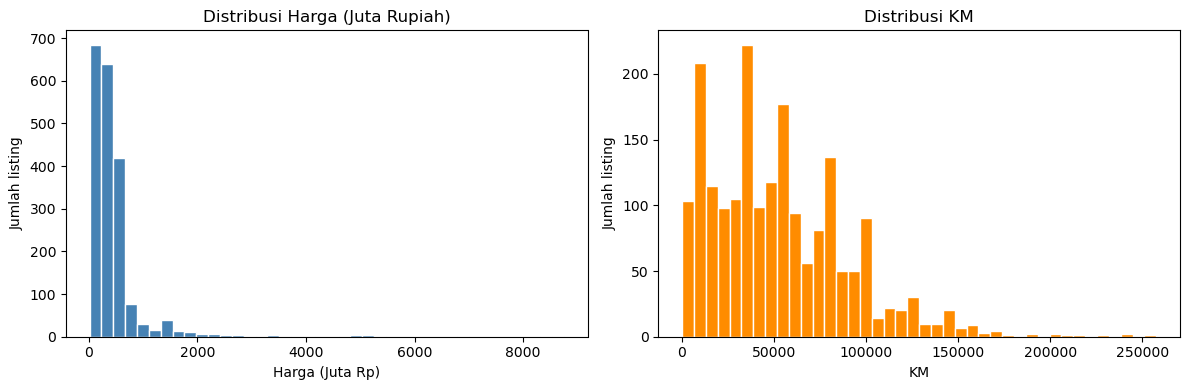

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model['harga'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga (Juta Rupiah)')
axes[0].set_xlabel('Harga (Juta Rp)')
axes[0].set_ylabel('Jumlah listing')

axes[1].hist(df_model['km'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi KM')
axes[1].set_xlabel('KM')
axes[1].set_ylabel('Jumlah listing')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_distribusi_harga_km.png', dpi=150, bbox_inches='tight')
plt.show()


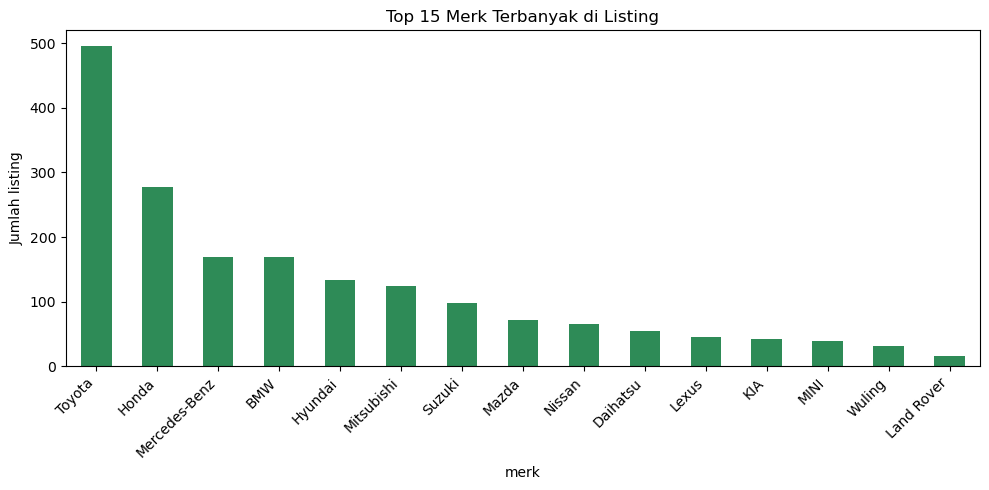

In [13]:
top_merk = df_model['merk'].value_counts().head(15)
plt.figure(figsize=(10, 5))
top_merk.plot(kind='bar', color='seagreen')
plt.title('Top 15 Merk Terbanyak di Listing')
plt.ylabel('Jumlah listing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_top15_merk.png', dpi=150, bbox_inches='tight')
plt.show()


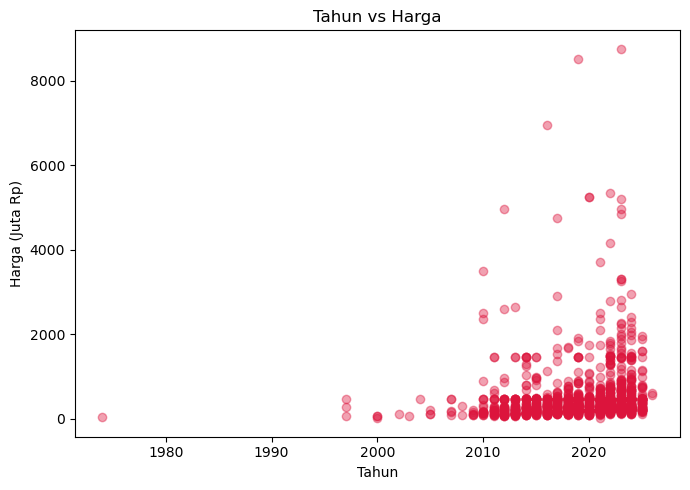

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df_model['tahun'], df_model['harga'] / 1e6, alpha=0.4, color='crimson')
plt.title('Tahun vs Harga')
plt.xlabel('Tahun')
plt.ylabel('Harga (Juta Rp)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_tahun_vs_harga.png', dpi=150, bbox_inches='tight')
plt.show()


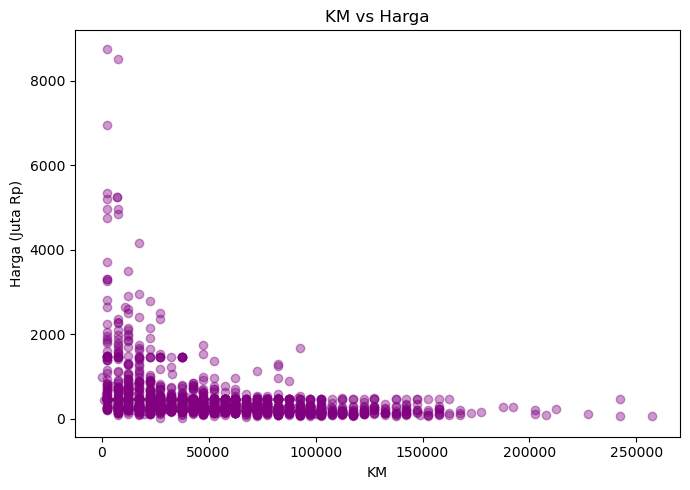

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df_model['km'], df_model['harga'] / 1e6, alpha=0.4, color='purple')
plt.title('KM vs Harga')
plt.xlabel('KM')
plt.ylabel('Harga (Juta Rp)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_km_vs_harga.png', dpi=150, bbox_inches='tight')
plt.show()


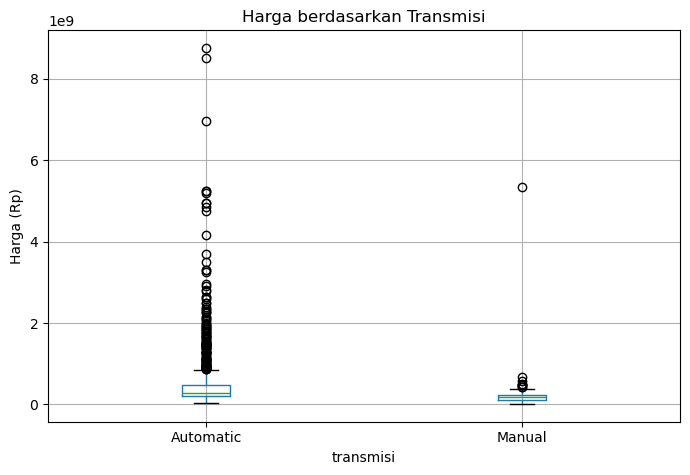

In [16]:
fig = df_model.boxplot(column='harga', by='transmisi', figsize=(7, 5))
plt.title('Harga berdasarkan Transmisi')
plt.suptitle('')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_harga_by_transmisi.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 900x500 with 0 Axes>

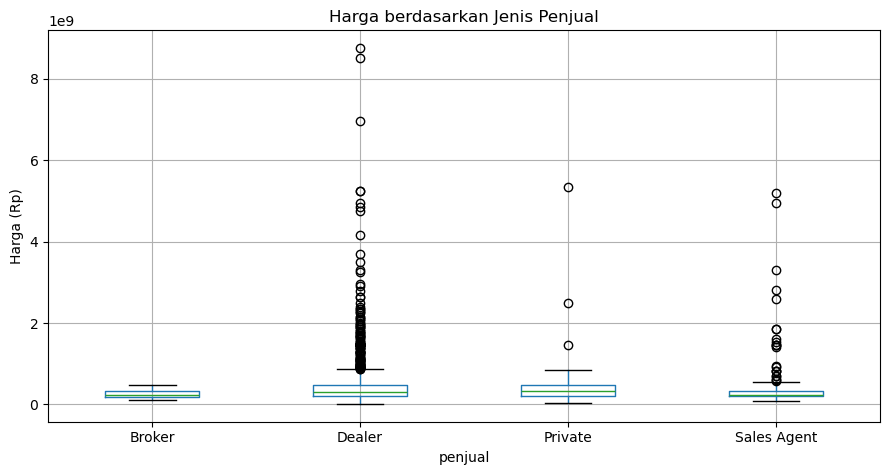

In [17]:
plt.figure(figsize=(9, 5))
df_model.boxplot(column='harga', by='penjual', figsize=(9, 5))
plt.title('Harga berdasarkan Jenis Penjual')
plt.suptitle('')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_harga_by_penjual.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# Kolom numerik untuk korelasi: tahun, km, harga, plus semua kolom dummy jenis mobil
# (is_suv, is_mpv, dst) yang nilainya 0/1 sehingga korelasinya juga valid dihitung.
dummy_cols_model = [c for c in df_model.columns if c.startswith('is_')]
numeric_cols = ['tahun', 'km', 'harga'] + dummy_cols_model
numeric_df = df_model[numeric_cols]

corr_matrix = numeric_df.corr()
print(corr_matrix.round(2))


                tahun    km  harga  is_convertible  is_coupe  is_fastback  \
tahun            1.00 -0.60   0.11           -0.06     -0.04         0.03   
km              -0.60  1.00  -0.32           -0.06     -0.17        -0.05   
harga            0.11 -0.32   1.00            0.17      0.34         0.08   
is_convertible  -0.06 -0.06   0.17            1.00     -0.01        -0.00   
is_coupe        -0.04 -0.17   0.34           -0.01      1.00        -0.01   
is_fastback      0.03 -0.05   0.08           -0.00     -0.01         1.00   
is_hatchback    -0.03  0.02  -0.14           -0.02     -0.07        -0.02   
is_mpv           0.01  0.21  -0.16           -0.04     -0.12        -0.03   
is_pickup        0.02 -0.01  -0.02           -0.00     -0.01        -0.00   
is_suv           0.09 -0.02   0.04           -0.06     -0.17        -0.04   
is_sedan        -0.12 -0.10   0.02           -0.02     -0.07        -0.02   
is_truck        -0.02 -0.01  -0.01           -0.00     -0.01        -0.00   

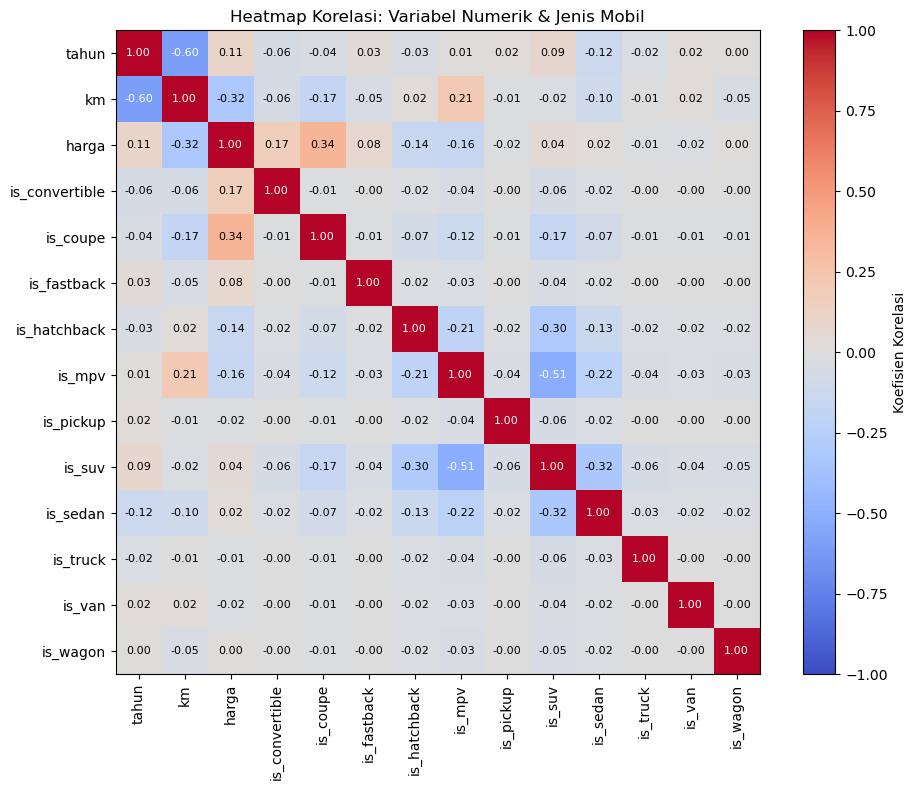

In [19]:
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Koefisien Korelasi')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# tampilkan angka korelasi di tiap sel
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.title('Heatmap Korelasi: Variabel Numerik & Jenis Mobil')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Uji Korelasi dan Regresi Linear Berganda (Sinkron dengan Pipeline)

Sebelum membangun model, uji korelasi terhadap variabel numerik dilakukan di bagian EDA.
Model di bawah disusun agar konsisten dengan `preprocess_mobil123.py` dan dashboard website.

**Jenis model:** Regresi Linear Berganda (multiple linear regression).

**Skema sinkron pipeline:**
- Gunakan fitur yang sama untuk dua model: model target `harga` (baseline) dan model target `log_harga`.
- Variabel tahun ditransformasikan jadi `usia_mobil = 2026 - tahun` agar lebih stabil untuk interpretasi.
- Fitur kategorikal di-*one-hot encode* dengan `drop='first'` untuk mengurangi risiko multikolinearitas sempurna.

**Variabel Dependen (Y):**
- Baseline: `harga` (Rupiah)
- Model utama: `log_harga`

**Variabel Independen (X):**
- `usia_mobil` (numerik)
- `km` (numerik)
- `merk` (kategorikal, one-hot)
- `transmisi` (kategorikal, one-hot)
- `penjual` (kategorikal, one-hot)
- `jenis_mobil` (kategorikal, one-hot)
- seluruh kolom dummy `is_...` (hasil ekstraksi jenis mobil)

Pendekatan ini membuat hasil notebook konsisten dengan hasil di script Python dan website.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Sinkron dengan pipeline: gunakan usia_mobil + fitur kategorikal lengkap
df_model['usia_mobil'] = 2026 - df_model['tahun']
df_model['log_harga'] = np.log(df_model['harga'])

dummy_cols_model = [c for c in df_model.columns if c.startswith('is_')]
feature_cols = ['usia_mobil', 'km', 'merk', 'transmisi', 'penjual', 'jenis_mobil'] + dummy_cols_model

X = df_model[feature_cols]
y_raw = df_model['harga']
y_log = df_model['log_harga']

categorical_cols = ['merk', 'transmisi', 'penjual', 'jenis_mobil']
numeric_cols = ['usia_mobil', 'km'] + dummy_cols_model

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
], remainder='passthrough')

raw_model = Pipeline([
    ('prep', preprocessor),
    ('lr', LinearRegression())
])

log_model = Pipeline([
    ('prep', preprocessor),
    ('lr', LinearRegression())
])

X_train, X_test, y_raw_train, y_raw_test, y_log_train, y_log_test = train_test_split(
    X, y_raw, y_log, test_size=0.2, random_state=42
)

raw_model.fit(X_train, y_raw_train)
pred_raw = raw_model.predict(X_test)

log_model.fit(X_train, y_log_train)
pred_log = log_model.predict(X_test)
pred_log_to_rupiah = np.exp(pred_log)

print('Variabel independen (X):', feature_cols)
print('Variabel dependen baseline: harga')
print('Variabel dependen utama: log_harga')
print()
print('Baseline  - R2 (test, harga):', r2_score(y_raw_test, pred_raw))
print('Baseline  - MAE (test, harga):', mean_absolute_error(y_raw_test, pred_raw))
print('Model log - R2 (test, skala log):', r2_score(y_log_test, pred_log))
print('Model log - MAE (test, Rupiah):', mean_absolute_error(y_raw_test, pred_log_to_rupiah))

# untuk kompatibilitas cell visualisasi berikutnya
model = raw_model
pred = pred_raw
y_test = y_raw_test

Variabel independen (X): ['usia_mobil', 'km', 'merk', 'transmisi', 'penjual', 'jenis_mobil', 'is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']
Variabel dependen baseline: harga
Variabel dependen utama: log_harga

Baseline  - R2 (test, harga): 0.2507865033153124
Baseline  - MAE (test, harga): 231775276.50894776
Model log - R2 (test, skala log): 0.5375962569354962
Model log - MAE (test, Rupiah): 189930988.04177865


/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


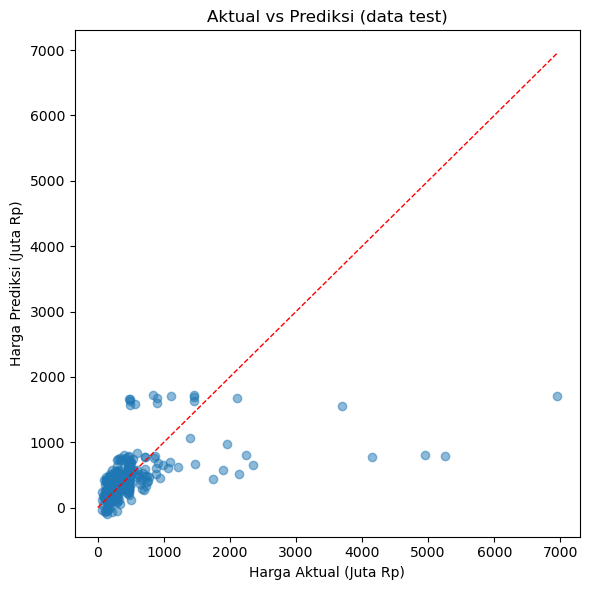

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test / 1e6, pred / 1e6, alpha=0.5)
lims = [0, max(y_test.max(), pred.max()) / 1e6]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Harga Aktual (Juta Rp)')
plt.ylabel('Harga Prediksi (Juta Rp)')
plt.title('Aktual vs Prediksi (data test)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_aktual_vs_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# fit ulang model log di seluruh data untuk melihat arah & besar pengaruh tiap variabel
log_model.fit(X, y_log)
lr = log_model.named_steps['lr']
feat_names = log_model.named_steps['prep'].get_feature_names_out()

coef_df = pd.DataFrame({'fitur': feat_names, 'koefisien': lr.coef_})
coef_df['efek_persen'] = (np.exp(coef_df['koefisien']) - 1) * 100
coef_df = coef_df.sort_values('koefisien', ascending=False)
coef_df.head(25)

,fitur,koefisien,efek_persen
50,cat__jenis_mobil_Coupe,0.429713,53.681670
64,remainder__is_coupe,0.429713,53.681670
24,cat__merk_Lexus,0.361346,43.525987
23,cat__merk_Land Rover,0.295718,34.409174
29,cat__merk_Mercedes-Benz,0.248850,28.254957
34,cat__merk_Porsche,0.237950,26.864569
2,cat__merk_BMW,0.223884,25.092553
63,remainder__is_convertible,0.174972,19.121295
48,cat__penjual_Private,0.158708,17.199553
26,cat__merk_MINI,0.143411,15.420457


**Catatan interpretasi koefisien (model log):**
- Koefisien dibaca pada skala log; pendekatan praktisnya bisa dikonversi ke persentase perubahan
  harga dengan rumus `efek (%) = (exp(koefisien) - 1) * 100`.
- Untuk variabel kategorikal (`merk`, `transmisi`, `penjual`, `jenis_mobil`) yang di-*one-hot encode*,
  koefisien menunjukkan selisih relatif terhadap kategori dasar.

**Hal yang perlu diperhatikan:**
- Beberapa merk/jenis masih punya jumlah listing kecil sehingga estimasi koefisiennya bisa kurang stabil.
- Nilai metrik berasal dari satu kali *train-test split*; untuk evaluasi yang lebih stabil, gunakan
  *cross-validation*.
- Walau sudah sinkron dengan pipeline, model linear tetap bisa underfit untuk pola harga yang non-linear.

## 6. Uji Asumsi Klasik

Karena model di atas adalah **regresi linear berganda**, perlu dilakukan uji asumsi
klasik untuk memastikan model valid secara statistik: (1) **multikolinearitas**
antar variabel independen, (2) **heteroskedastisitas** pada residual, dan
(3) **normalitas** residual.


### 6.1 Uji Multikolinearitas (VIF)

VIF (*Variance Inflation Factor*) mengukur seberapa besar suatu variabel independen
berkorelasi dengan variabel independen lainnya. **Aturan umum:** VIF > 10 menunjukkan
multikolinearitas yang serius; VIF > 5 perlu diwaspadai.


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def build_vif_diagnostic_frame(encoded_df):
    diagnostic_df = encoded_df.copy()
    redundant_cols = [col for col in diagnostic_df.columns if col.startswith('remainder__is_')]
    if redundant_cols:
        diagnostic_df = diagnostic_df.drop(columns=redundant_cols)
    diagnostic_df = diagnostic_df.loc[:, diagnostic_df.nunique(dropna=False) > 1]
    return diagnostic_df


# VIF diagnostik: buang dummy body-type yang redundan agar tidak ada multikolinearitas sempurna
vif_diag_df = build_vif_diagnostic_frame(X_encoded_df)
vif_data = pd.DataFrame({
    'fitur': vif_diag_df.columns,
    'VIF': [variance_inflation_factor(vif_diag_df.values, i) for i in range(vif_diag_df.shape[1])],
})
vif_data = vif_data.replace([np.inf, -np.inf], np.nan).sort_values('VIF', ascending=False)
print(vif_data.head(20).to_string(index=False))

n_high_vif = int((vif_data['VIF'] > 10).sum())
print(f'Jumlah fitur dengan VIF > 10 (diagnostik, tanpa kolom dummy redundan): {n_high_vif}')

                     fitur        VIF
      cat__jenis_mobil_SUV 128.552965
          cat__merk_Toyota  86.625670
      cat__jenis_mobil_MPV  79.935813
           cat__merk_Honda  48.652735
       cat__penjual_Dealer  41.230440
    cat__jenis_mobil_Sedan  37.227094
cat__jenis_mobil_Hatchback  33.918039
   cat__merk_Mercedes-Benz  29.812983
             cat__merk_BMW  29.496218
         cat__merk_Hyundai  23.783542
      cat__merk_Mitsubishi  22.606319
          cat__merk_Suzuki  18.166352
           cat__merk_Mazda  13.470737
          cat__merk_Nissan  12.455925
    cat__jenis_mobil_Coupe  11.806789
  cat__penjual_Sales Agent  11.365633
        cat__merk_Daihatsu  10.241660
           cat__merk_Lexus   9.079143
     remainder__usia_mobil   8.822795
             cat__merk_KIA   8.350935
Jumlah fitur dengan VIF > 10 (diagnostik, tanpa kolom dummy redundan): 17


### 6.2 Uji Heteroskedastisitas (Residual Plot)

Residual (selisih nilai aktual - prediksi) diplot terhadap nilai prediksi. **Asumsi
terpenuhi** kalau titik-titik tersebar acak di sekitar garis 0 tanpa pola corong
(melebar/menyempit) -- itu disebut *homoskedastisitas*. Kalau ada pola corong, berarti
*heteroskedastisitas* (varians residual tidak konstan).


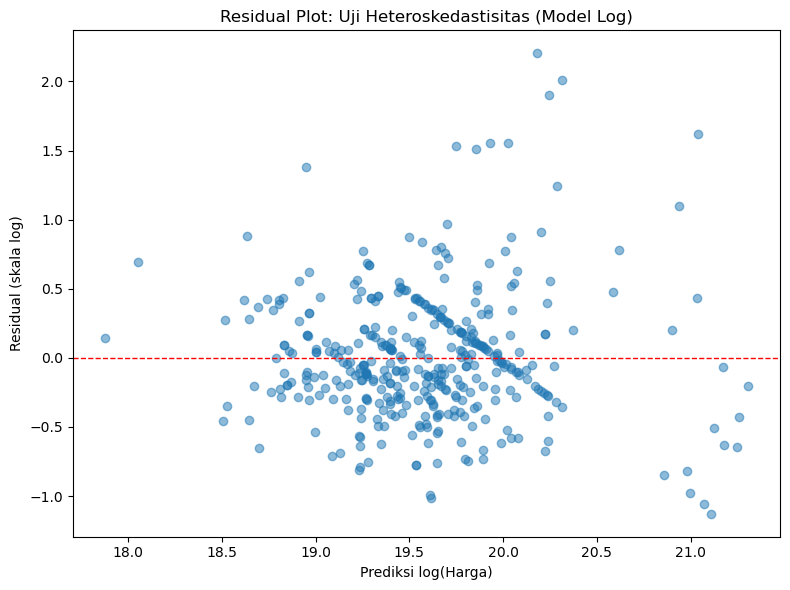

In [24]:
# Residual untuk model log dihitung pada skala log
residuals = y_log_test - pred_log

plt.figure(figsize=(8, 6))
plt.scatter(pred_log, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Prediksi log(Harga)')
plt.ylabel('Residual (skala log)')
plt.title('Residual Plot: Uji Heteroskedastisitas (Model Log)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Uji Normalitas Residual

Diuji dengan dua cara: **histogram residual** (visual, bentuknya harus mendekati
kurva normal/lonceng simetris) dan **uji Shapiro-Wilk** (statistik, H0 = residual
berdistribusi normal; kalau p-value < 0.05 maka H0 ditolak, artinya residual
**tidak** berdistribusi normal).


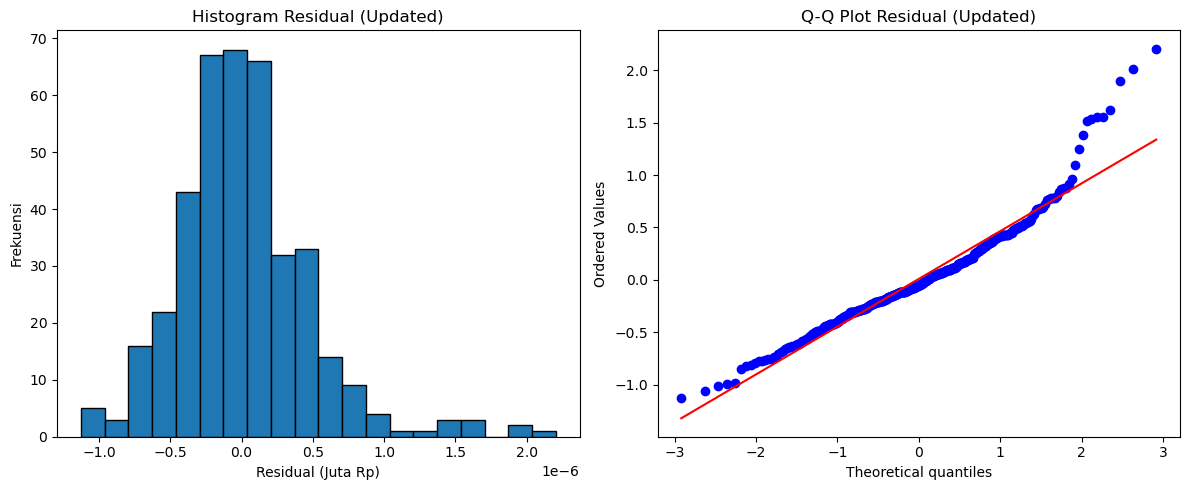

Shapiro-Wilk statistic: 0.9411, p-value: 0.0000
-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).


In [25]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram residual
axes[0].hist(residuals / 1e6, bins=20, edgecolor='black')
axes[0].set_xlabel('Residual (Juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Histogram Residual (Updated)')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Residual (Updated)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_normalitas_residual.png', dpi=150, bbox_inches='tight')
plt.show()

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).")
else:
    print("-> p-value >= 0.05: tidak cukup bukti untuk menolak normalitas residual.")


**Catatan:** Uji Shapiro-Wilk cukup sensitif pada ukuran sampel besar (>1000 baris) --
sering menghasilkan p-value kecil meskipun penyimpangan dari normalitas sebenarnya
kecil/tidak terlalu bermasalah secara praktis. Untuk sampel besar, lebih baik
mengandalkan visual (histogram & Q-Q plot) dibanding p-value semata.


## 7. Validasi Lanjutan & Ringkasan Perbaikan Model

Bagian ini merangkum dampak transformasi `log_harga` dan penggunaan `usia_mobil` yang
sudah diterapkan di model utama pada Bagian 5.

Fokus validasi:
1. Cek bentuk distribusi `harga` vs `log_harga`.
2. Konfirmasi ulang metrik model log pada hold-out test set.
3. Cek ulang VIF dan perilaku residual pada model log sebagai model utama.

In [26]:
# df_model sudah memiliki usia_mobil dan log_harga dari Bagian 5
print(df_model[['tahun', 'usia_mobil', 'harga', 'log_harga']].head())
print()
print('Skewness harga asli :', df_model['harga'].skew().round(3))
print('Skewness log(harga) :', df_model['log_harga'].skew().round(3))

   tahun  usia_mobil        harga  log_harga
0   2013          13  230000000.0  19.253590
1   2019           7  466564618.0  19.960907
2   2022           4  189000000.0  19.057258
3   2017           9  466564618.0  19.960907
4   2025           1  466564618.0  19.960907

Skewness harga asli : 6.811
Skewness log(harga) : 0.871


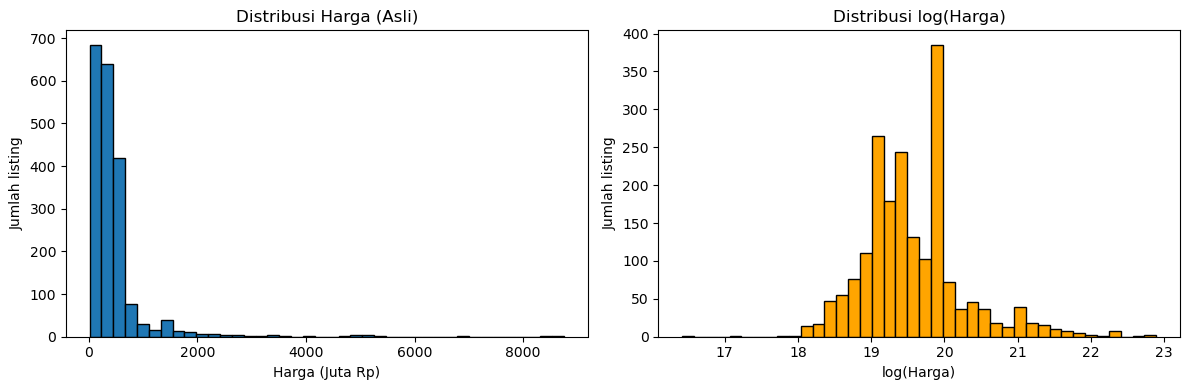

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model['harga'] / 1e6, bins=40, edgecolor='black')
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga (Juta Rp)')
axes[0].set_ylabel('Jumlah listing')

axes[1].hist(df_model['log_harga'], bins=40, edgecolor='black', color='orange')
axes[1].set_title('Distribusi log(Harga)')
axes[1].set_xlabel('log(Harga)')
axes[1].set_ylabel('Jumlah listing')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_distribusi_log_harga.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Ringkas ulang metrik model sinkron (menggunakan hasil prediksi dari Bagian 5)
print('Variabel independen (X):', feature_cols)
print('Variabel dependen utama (y): log_harga')
print()
print('R2 (test, skala log):', r2_score(y_log_test, pred_log))
print('MAE (test, skala Rupiah):', mean_absolute_error(y_raw_test, pred_log_to_rupiah))

# Perbandingan langsung dengan baseline
print()
print('Perbandingan model:')
print('- Baseline harga mentah -> R2:', round(r2_score(y_raw_test, pred_raw), 4),
      '| MAE:', round(mean_absolute_error(y_raw_test, pred_raw), 2))
print('- Model log(harga)     -> R2:', round(r2_score(y_log_test, pred_log), 4),
      '| MAE:', round(mean_absolute_error(y_raw_test, pred_log_to_rupiah), 2))

Variabel independen (X): ['usia_mobil', 'km', 'merk', 'transmisi', 'penjual', 'jenis_mobil', 'is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']
Variabel dependen utama (y): log_harga

R2 (test, skala log): 0.5375962569354962
MAE (test, skala Rupiah): 189930988.04177865

Perbandingan model:
- Baseline harga mentah -> R2: 0.2508 | MAE: 231775276.51
- Model log(harga)     -> R2: 0.5376 | MAE: 189930988.04


**Perbandingan model (sinkron pipeline):**

| Model | Target | R² (test) | MAE (test, Rupiah) |
|---|---|---|---|
| Baseline MLR | `harga` | *lihat output Bagian 5* | *lihat output Bagian 5* |
| MLR utama | `log_harga` | *lihat output Bagian 5* | *lihat output Bagian 5* |

Interpretasi singkat: model `log_harga` biasanya lebih stabil untuk data harga yang sangat
right-skewed dan cenderung memberi error absolut yang lebih rendah saat dikonversi kembali
ke skala Rupiah.

### 7.1 Cek Ulang VIF Setelah `usia_mobil`


In [33]:
# Cek ulang VIF diagnostik setelah memasukkan usia_mobil.
# Matriks yang dipakai tetap diagnosis-only, bukan pipeline website.
vif_diag_df2 = build_vif_diagnostic_frame(X_encoded_df2)
vif_data2 = pd.DataFrame({
    'fitur': vif_diag_df2.columns,
    'VIF': [variance_inflation_factor(vif_diag_df2.values, i) for i in range(vif_diag_df2.shape[1])],
})
vif_data2 = vif_data2.replace([np.inf, -np.inf], np.nan).sort_values('VIF', ascending=False)
print(vif_data2.head(10).to_string(index=False))

n_high_vif2 = int((vif_data2['VIF'] > 10).sum())
print(f'Jumlah fitur dengan VIF > 10 (diagnostik, tanpa kolom dummy redundan): {n_high_vif2}')

                     fitur        VIF
      cat__jenis_mobil_SUV 128.552965
          cat__merk_Toyota  86.625670
      cat__jenis_mobil_MPV  79.935813
           cat__merk_Honda  48.652735
       cat__penjual_Dealer  41.230440
    cat__jenis_mobil_Sedan  37.227094
cat__jenis_mobil_Hatchback  33.918039
   cat__merk_Mercedes-Benz  29.812983
             cat__merk_BMW  29.496218
         cat__merk_Hyundai  23.783542
Jumlah fitur dengan VIF > 10 (diagnostik, tanpa kolom dummy redundan): 17


### 7.2 Cek Ulang Heteroskedastisitas & Normalitas Residual (Model Log)

Residual di sini dihitung pada skala **log**, karena itulah skala yang sebenarnya
dipakai untuk fitting model.


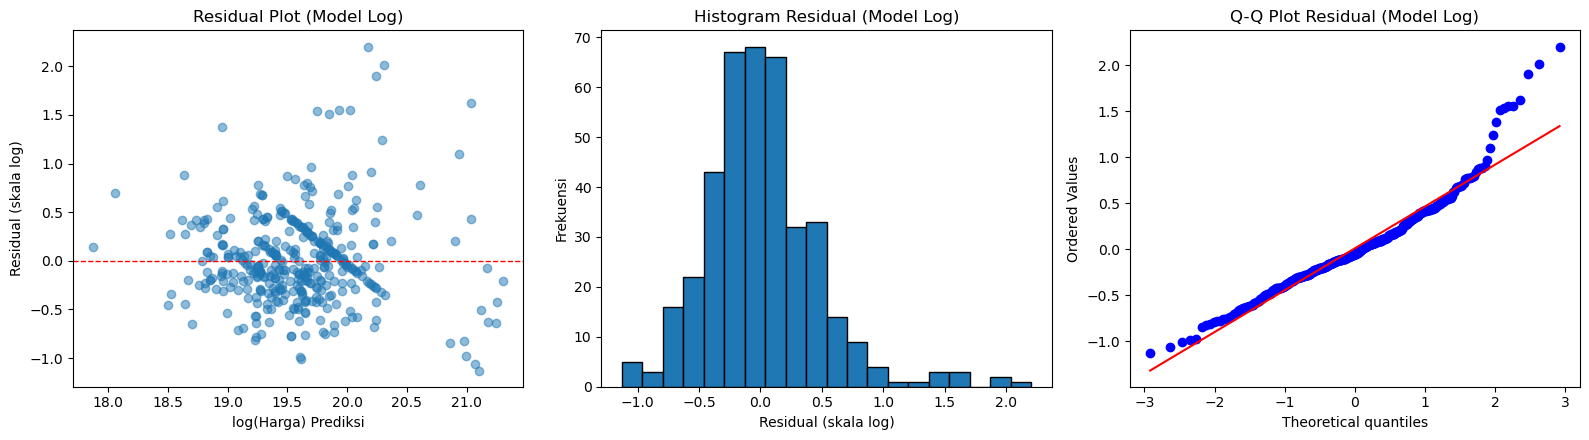

Shapiro-Wilk (model log) statistic: 0.9411, p-value: 0.0000
-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).


In [31]:
# residual model log (konsisten dengan pipeline)
residuals_log = y_log_test - pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_log, residuals_log, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('log(Harga) Prediksi')
axes[0].set_ylabel('Residual (skala log)')
axes[0].set_title('Residual Plot (Model Log)')

axes[1].hist(residuals_log, bins=20, edgecolor='black')
axes[1].set_xlabel('Residual (skala log)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Histogram Residual (Model Log)')

stats.probplot(residuals_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot Residual (Model Log)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_residual_model_log.png', dpi=150, bbox_inches='tight')
plt.show()

shapiro_stat2, shapiro_p2 = stats.shapiro(residuals_log)
print(f'Shapiro-Wilk (model log) statistic: {shapiro_stat2:.4f}, p-value: {shapiro_p2:.4f}')
if shapiro_p2 < 0.05:
    print('-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).')
else:
    print('-> p-value >= 0.05: tidak cukup bukti untuk menolak normalitas residual.')

**Catatan untuk laporan:** Transformasi log umumnya membantu pada data harga yang
skewed, tapi belum tentu membuat semua asumsi klasik terpenuhi sempurna -- apalagi
kalau outlier ekstrem (misal mobil Ferrari/Porsche di tengah dominasi mobil keluarga)
tetap ada. Kalau setelah log-transform residual masih belum normal, opsi lanjutan yang
bisa dibahas di laporan (sebagai *future work*, tidak harus dieksekusi semua):
- Menganalisis outlier mobil mewah secara terpisah (model khusus, atau di-exclude dengan
  alasan yang dijelaskan).
- Mencoba model non-linear (Random Forest, Gradient Boosting) sebagai pembanding, untuk
  menunjukkan bahwa keterbatasan ini bukan soal kesalahan coding, tapi karakteristik data.
- Winsorizing / capping outlier harga pada persentil tertentu (misal 1% & 99%).


In [34]:
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, r2_score


def format_rupiah(value):
    return f"Rp {value:,.0f}".replace(',', '.')


summary_rows = [
    ['Audit data', 'Baris raw', len(df_raw)],
    ['Audit data', 'Baris clean', len(df_clean)],
    ['Audit data', 'Harga kosong awal', n_missing_harga_asli],
    ['Audit data', 'Harga kosong akhir', n_missing_harga_final],
    ['Audit data', 'Jenis kosong', n_missing_jenis],
    ['Audit data', 'Harga terimputasi', n_imputed],
    ['Audit data', 'Baris yang bisa diimputasi', n_imputable],
    ['Audit data', 'VIF > 10 diagnostik awal', n_high_vif],
    ['Audit data', 'VIF > 10 diagnostik setelah usia_mobil', n_high_vif2],
    ['Model baseline', 'R2 test', round(r2_score(y_raw_test, pred_raw), 4)],
    ['Model baseline', 'MAE test', format_rupiah(mean_absolute_error(y_raw_test, pred_raw))],
    ['Model log', 'R2 test', round(r2_score(y_log_test, pred_log), 4)],
    ['Model log', 'MAE test', format_rupiah(mean_absolute_error(y_raw_test, pred_log_to_rupiah))],
    ['Diagnostik residual', 'Shapiro-Wilk statistic', round(shapiro_stat2, 4)],
    ['Diagnostik residual', 'Shapiro-Wilk p-value', round(shapiro_p2, 4)],
]

summary_df = pd.DataFrame(summary_rows, columns=['Kategori', 'Item', 'Nilai'])

display(Markdown('### Executive Summary'))
display(summary_df)

print('Kesimpulan singkat:')
print(f"- Model log lebih baik dari baseline pada test set: R2 {r2_score(y_log_test, pred_log):.4f} vs {r2_score(y_raw_test, pred_raw):.4f}.")
print(f"- MAE model log pada skala Rupiah: {format_rupiah(mean_absolute_error(y_raw_test, pred_log_to_rupiah))}.")
print(f"- Residual model log masih tidak normal (Shapiro p-value = {shapiro_p2:.4f}).")

### Executive Summary

,Kategori,Item,Nilai
0,Audit data,Baris raw,2061
1,Audit data,Baris clean,1975
2,Audit data,Harga kosong awal,504
3,Audit data,Harga kosong akhir,12
4,Audit data,Jenis kosong,53
5,Audit data,Harga terimputasi,492
6,Audit data,Baris yang bisa diimputasi,492
7,Audit data,VIF > 10 diagnostik awal,17
8,Audit data,VIF > 10 diagnostik setelah usia_mobil,17
9,Model baseline,R2 test,0.2508


Kesimpulan singkat:
- Model log lebih baik dari baseline pada test set: R2 0.5376 vs 0.2508.
- MAE model log pada skala Rupiah: Rp 189.930.988.
- Residual model log masih tidak normal (Shapiro p-value = 0.0000).
